# Fraud / Anomaly Detection
## Notebook 03 — Exploratory Data Analysis

### Objective

Explore the cleaned transaction dataset to understand distributions, class imbalance, relationships between variables, and potential patterns that may be useful for unsupervised anomaly detection.

### Important Principle

The `Class` column will be used only for exploratory analysis and later evaluation. It will not be used as an input feature for unsupervised model training.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/processed/creditcard_cleaned.csv")

In [9]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
df.shape

(283726, 31)

In [13]:
normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

print("Normal transactions:", len(normal))
print("Fraudulent transactions:", len(fraud))

Normal transactions: 283253
Fraudulent transactions: 473


In [15]:
fraud_percentage = (
    df["Class"].value_counts(normalize=True) * 100
)

fraud_percentage

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [17]:
fraud_rate = (df["Class"].sum() / len(df)) * 100

print(f"Fraud rate: {fraud_rate:.4f}%")

Fraud rate: 0.1667%


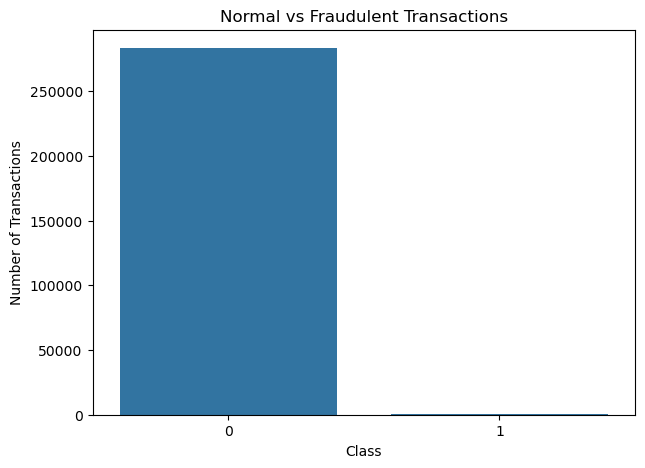

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [21]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


In [23]:
print("Normal median amount:",
      normal["Amount"].median())

print("Fraud median amount:",
      fraud["Amount"].median())

Normal median amount: 22.0
Fraud median amount: 9.82


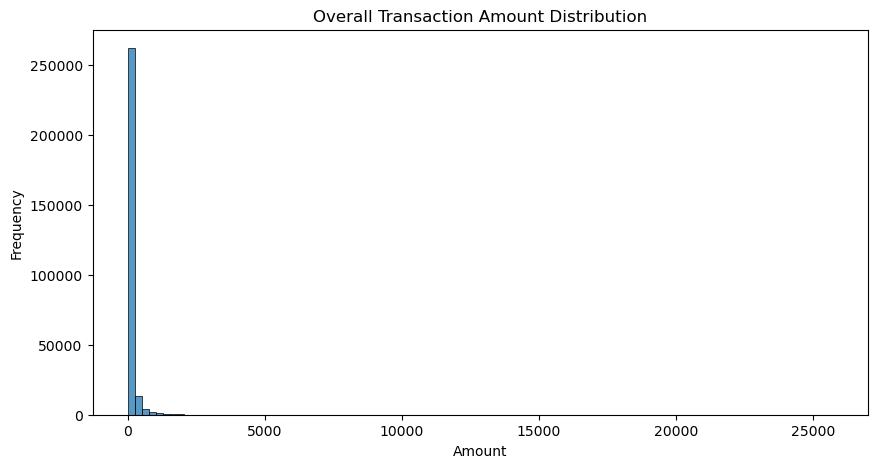

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    bins=100
)

plt.title("Overall Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

In [27]:
df["Amount_log"] = np.log1p(df["Amount"])

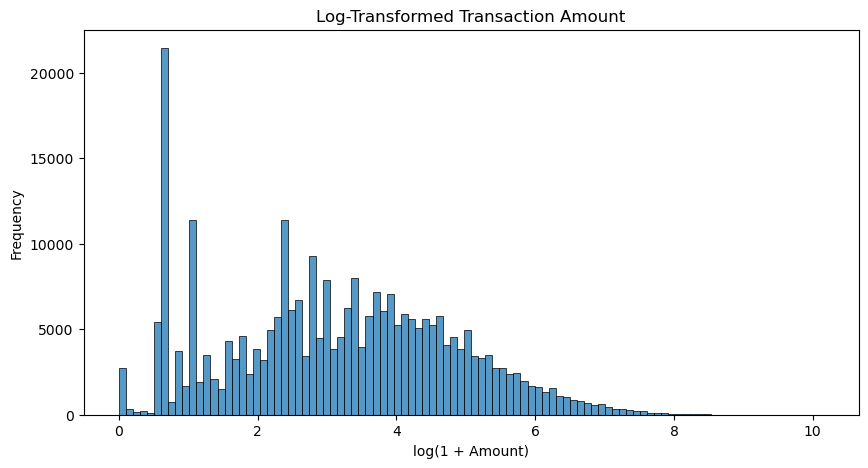

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount_log",
    bins=100
)

plt.title("Log-Transformed Transaction Amount")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Frequency")

plt.show()

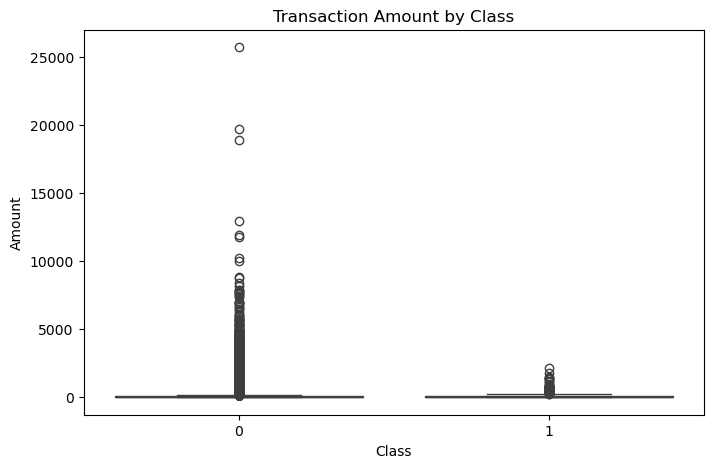

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

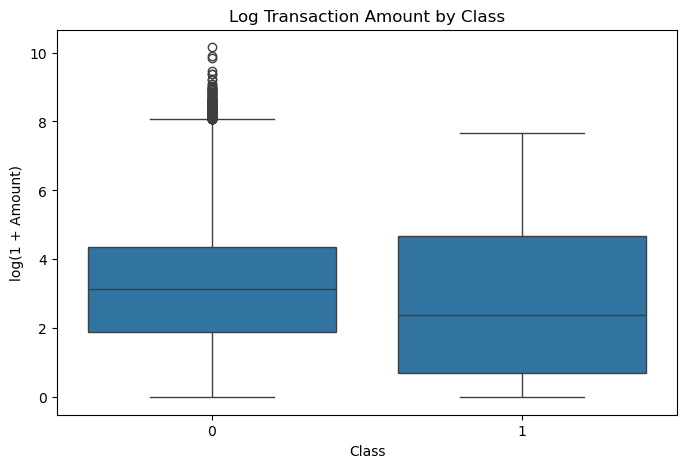

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount_log"
)

plt.title("Log Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("log(1 + Amount)")

plt.show()

In [35]:
print("Minimum time:", df["Time"].min())
print("Maximum time:", df["Time"].max())

Minimum time: 0.0
Maximum time: 172792.0


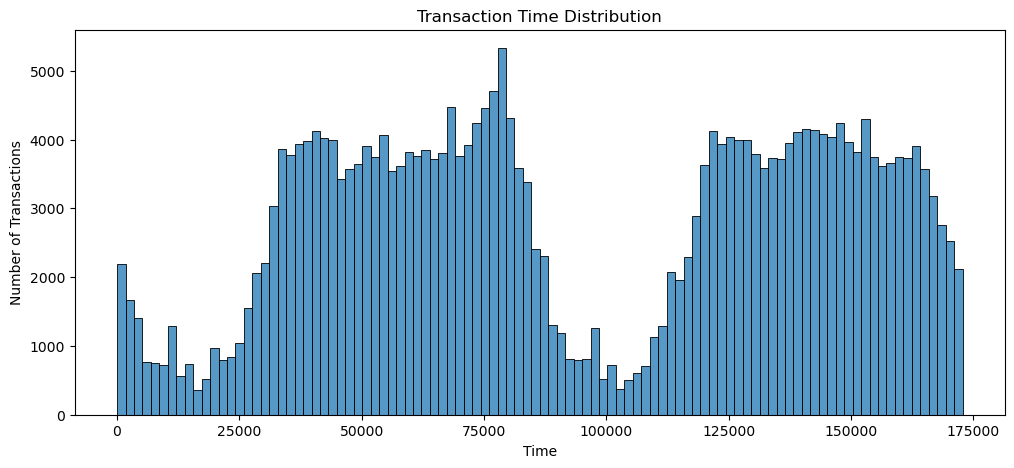

In [37]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time",
    bins=100
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

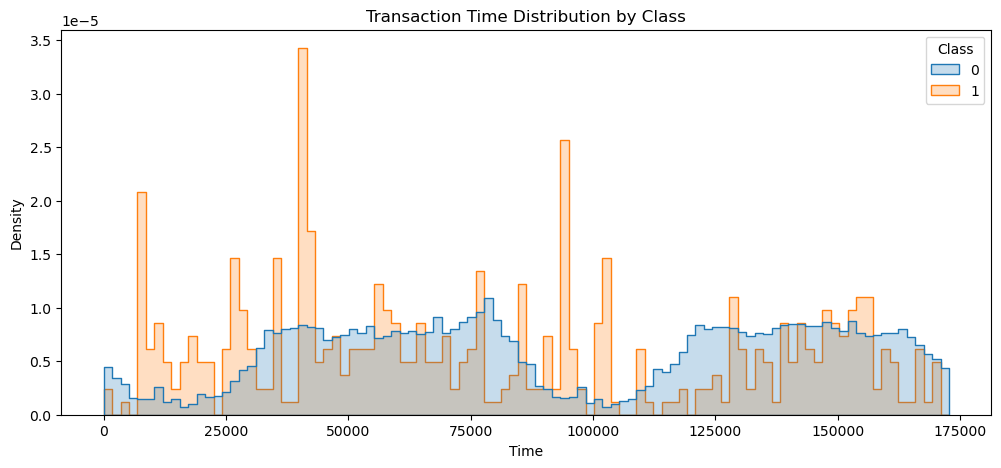

In [39]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time")
plt.ylabel("Density")

plt.show()

In [41]:
correlation = df.corr(numeric_only=True)

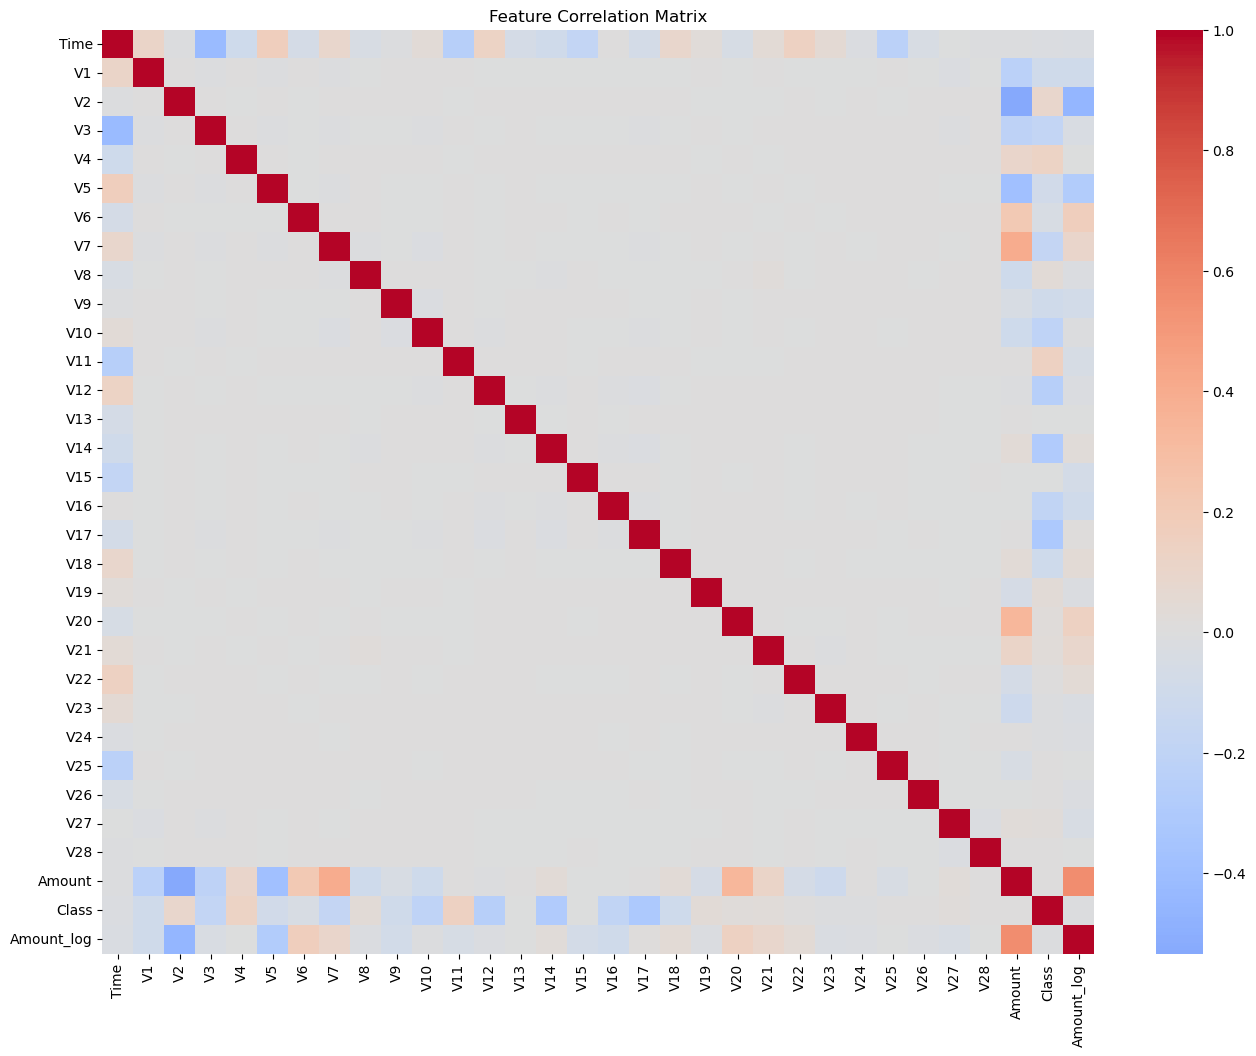

In [43]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [45]:
class_correlation = (
    correlation["Class"]
    .drop("Class")
    .sort_values()
)

class_correlation

V17          -0.313498
V14          -0.293375
V12          -0.250711
V10          -0.206971
V16          -0.187186
V3           -0.182322
V7           -0.172347
V18          -0.105340
V1           -0.094486
V9           -0.094021
V5           -0.087812
V6           -0.043915
Time         -0.012359
Amount_log   -0.007798
V24          -0.007210
V23          -0.006333
V13          -0.003897
V15          -0.003300
V25           0.003202
V26           0.004265
V22           0.004887
Amount        0.005777
V28           0.009682
V20           0.021486
V27           0.021892
V21           0.026357
V8            0.033068
V19           0.033631
V2            0.084624
V4            0.129326
V11           0.149067
Name: Class, dtype: float64

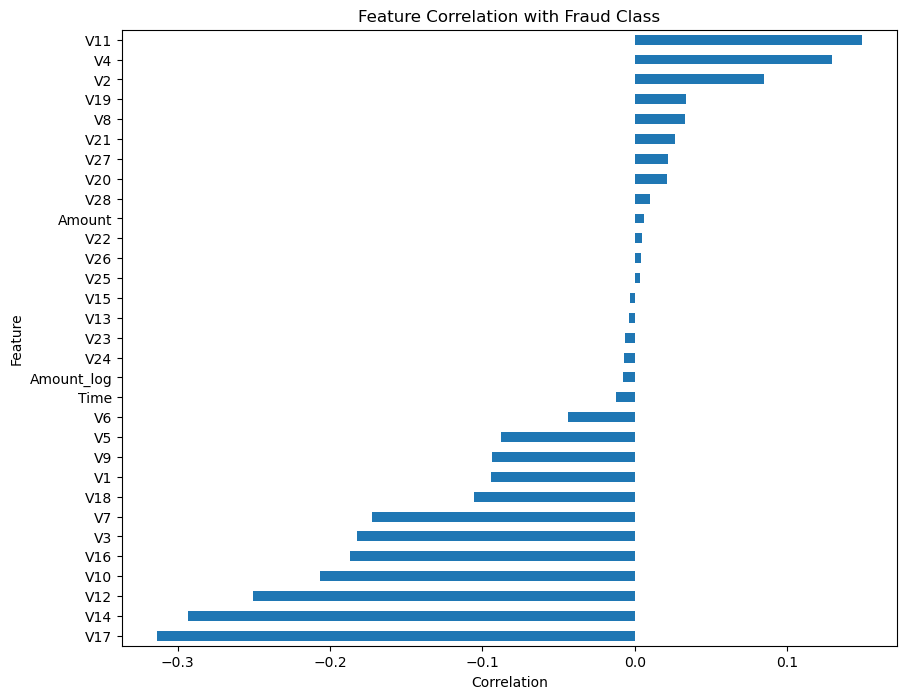

In [47]:
plt.figure(figsize=(10, 8))

class_correlation.plot(kind="barh")

plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

In [49]:
class_correlation.abs().sort_values(ascending=False).head(10)

V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64

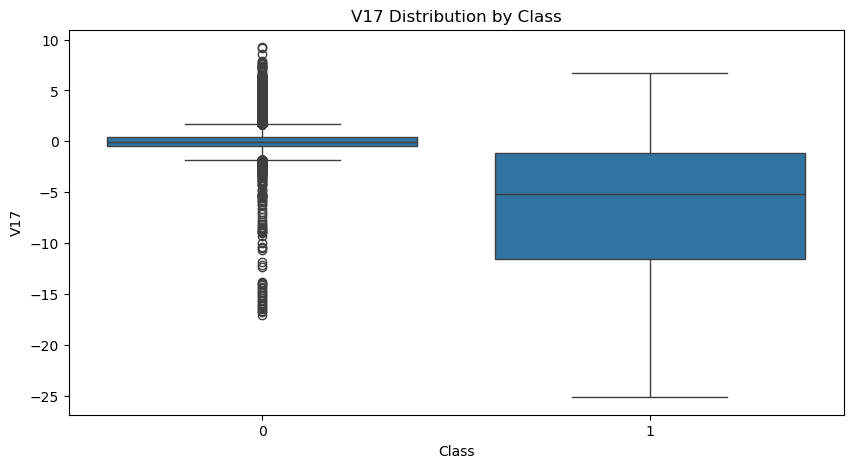

In [51]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="V17"
)

plt.title("V17 Distribution by Class")
plt.show()

In [53]:
top_feature = class_correlation.abs().idxmax()

print("Top correlated feature:", top_feature)

Top correlated feature: V17


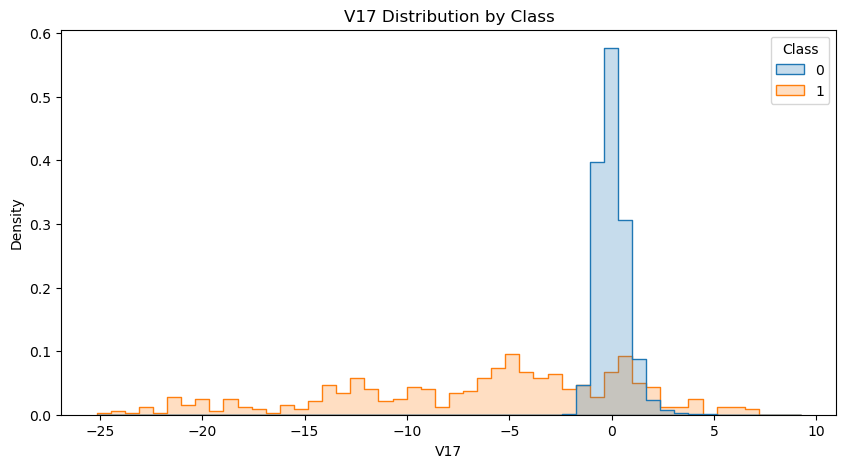

In [55]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x=top_feature,
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title(f"{top_feature} Distribution by Class")
plt.xlabel(top_feature)
plt.ylabel("Density")

plt.show()

In [57]:
df.nlargest(10, "Amount")[
    ["Time", "Amount", "Class"]
]

,Time,Amount,Class
273745,166198.0,25691.16,0
58220,48401.0,19656.53,0
150705,95286.0,18910.00,0
46641,42951.0,12910.93,0
53784,46253.0,11898.09,0
168820,119713.0,11789.84,0
283168,172273.0,10199.44,0
227081,145283.0,10000.00,0
74408,55709.0,8790.26,0
244563,152763.0,8787.00,0


# EDA Conclusions

## Key Findings

### 1. Class Imbalance
Fraudulent transactions represent only a very small percentage of the dataset.

### 2. Transaction Amount
Transaction amounts are highly skewed, with a small number of very large transactions.

### 3. Time
Transaction activity is not uniformly distributed across the recorded time period.

### 4. Feature Relationships
Several anonymized features show different distributions between normal and fraudulent transactions.

### 5. Anomaly Detection Motivation
Because fraudulent transactions are rare, an unsupervised anomaly detection approach is appropriate for identifying unusual transactions without using the fraud label during model training.

### 6. Important Modeling Decision
The `Class` column will not be included as a model feature.

It will be retained separately for evaluation.

### 7. Important Outlier Decision
Extreme values will not automatically be removed because unusual observations may represent genuine fraudulent activity.

In [59]:
fraud_rate

0.1667101358352777

In [61]:
class_correlation.abs().sort_values(ascending=False).head(10)

V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64

In [63]:
df["Amount_log"] = np.log1p(df["Amount"])

In [65]:
df = pd.read_csv("../data/processed/creditcard_cleaned.csv")

In [67]:
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [69]:
df.shape

(283726, 31)